Лабораторная 3

Возьмите один простой набор данных (MNIST, FMNIST, CIFAR-10 и т.д.).
Обучите на нём простую модель нейронной сети (не CNN!!!) с применением методов регуляризации и с функцией активации ReLU.
Архитектуру задаете сами. Постройте график значения функции потерь от количества эпох, а также график метрик качества от количества эпох


Загрузим датасет mnist

In [1]:
import tensorflow as tf

seed = 52

tf.random.set_seed(seed)

# Дополнительно для TensorFlow
tf.keras.utils.set_random_seed(seed)

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

Нормализуем

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Преобразуем в одномерный вектор

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
x_train.shape

(60000, 784)

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\mrsiz\PycharmProjects\ml-26-labs\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=0
)

Выведем графики значения функции потерь от количества эпох и график метрик качества от количества эпох

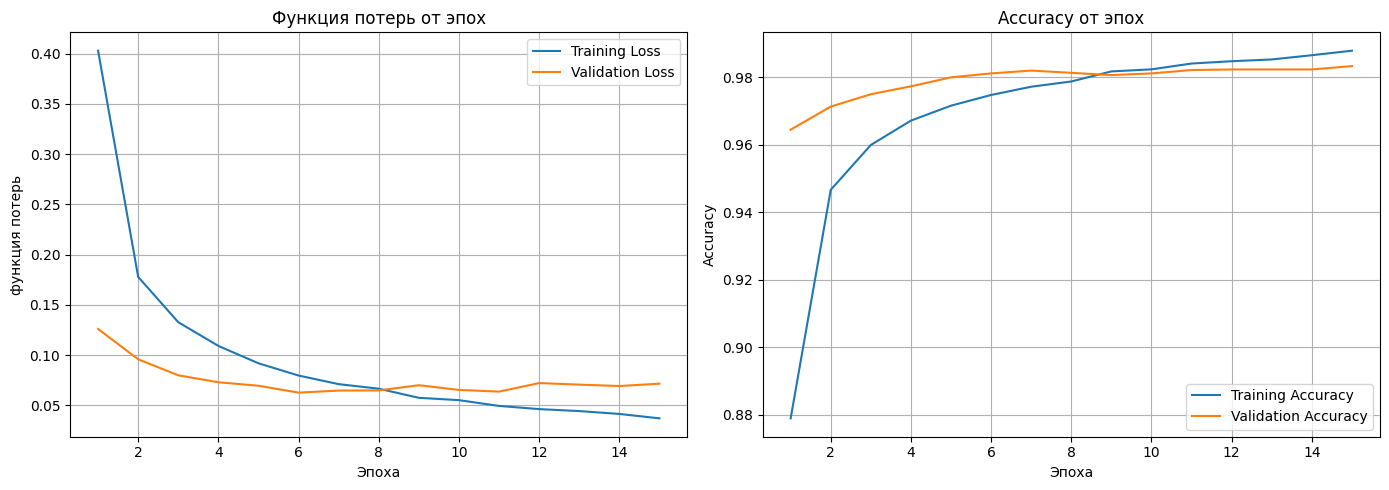

In [8]:
from matplotlib import pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, 16)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Функция потерь от эпох')
plt.xlabel('Эпоха')
plt.ylabel('функция потерь')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy от эпох')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

Уберите из архитектуры регуляризацию. Что стало с результатом? Постройте графики и сравните с оригинальной моделью


Создадим такую же модель без dropout и обучим

In [9]:
model_no_reg = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_no_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_reg = model_no_reg.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=0
)

Выведем графики

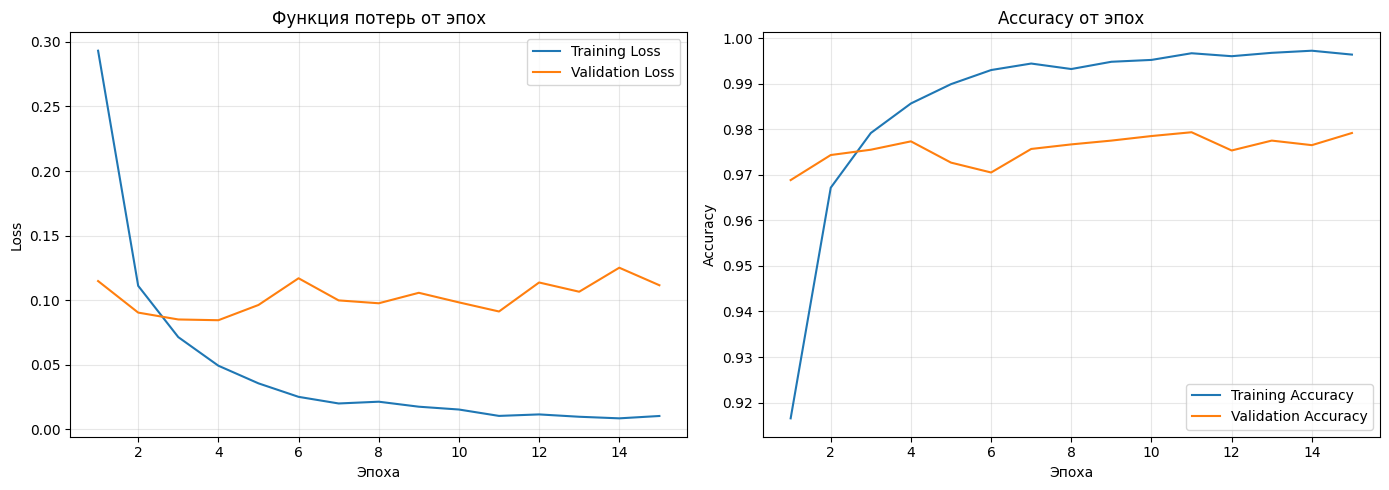

In [10]:
import matplotlib.pyplot as plt

acc = history_no_reg.history['accuracy']
val_acc = history_no_reg.history['val_accuracy']
loss = history_no_reg.history['loss']
val_loss = history_no_reg.history['val_loss']

plt.figure(figsize=(14, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss' )
plt.title('Функция потерь от эпох')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# График точности
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy от эпох')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Видим, что функция потерь падает почти до 0 на обучающей выборке, в то время как на валидационной выборке она гораздо выше.
Аналогично и с графиком accuracy: на обучающей выборке метрика растет выше, в то время как на валидационной выборке она гораздо ниже.
Все это из-за переобучения.

Замените ReLU на сигмоиду. Что стало с результатом? Если он ухудшился, то почему? Постройте графики и сравните с оригинальной моделью

In [11]:
# Модель с сигмоидой вместо ReLU
model_sigmoid = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='sigmoid'),  # ReLU → Sigmoid
    layers.Dropout(0.3),
    layers.Dense(128, activation='sigmoid'),  # ReLU → Sigmoid
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_sigmoid.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем
history_sigmoid = model_sigmoid.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=0
)

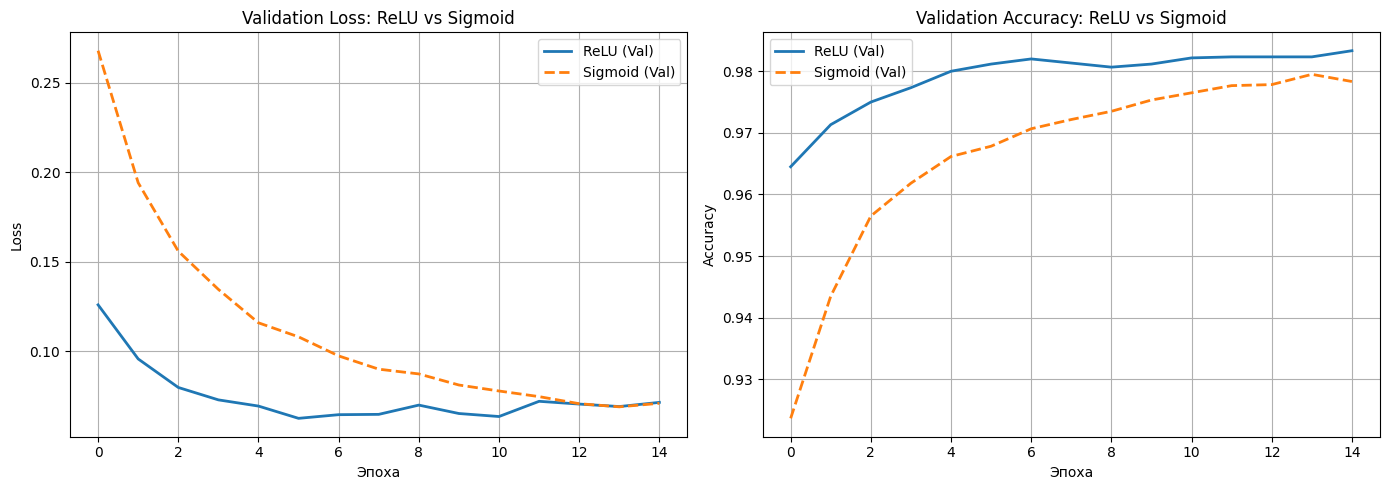

In [12]:
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='ReLU (Val)', linewidth=2)
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid (Val)', linestyle='--', linewidth=2)
plt.title('Validation Loss: ReLU vs Sigmoid')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='ReLU (Val)', linewidth=2)
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid (Val)', linestyle='--', linewidth=2)
plt.title('Validation Accuracy: ReLU vs Sigmoid')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Функция потерь падает медленнее.
Accuracy растет медленнее, в конечном итоге меньше чем у ReLu.
Все это из-за особенности sigmoid и ее недостатка в виде исчезающих градиентов.

Обучите простую CNN на выбранном датасете. Визуализируйте активации на первых слоях сети. Какие закономерности находит модель?


In [13]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [14]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=0
)

C:\Users\mrsiz\PycharmProjects\ml-26-labs\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


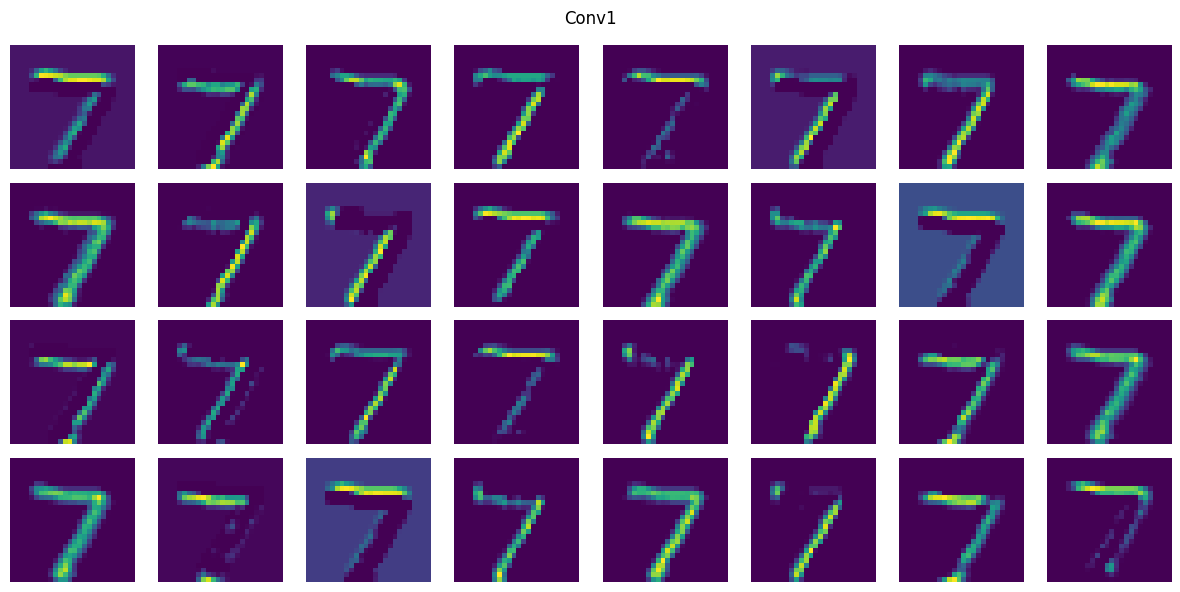

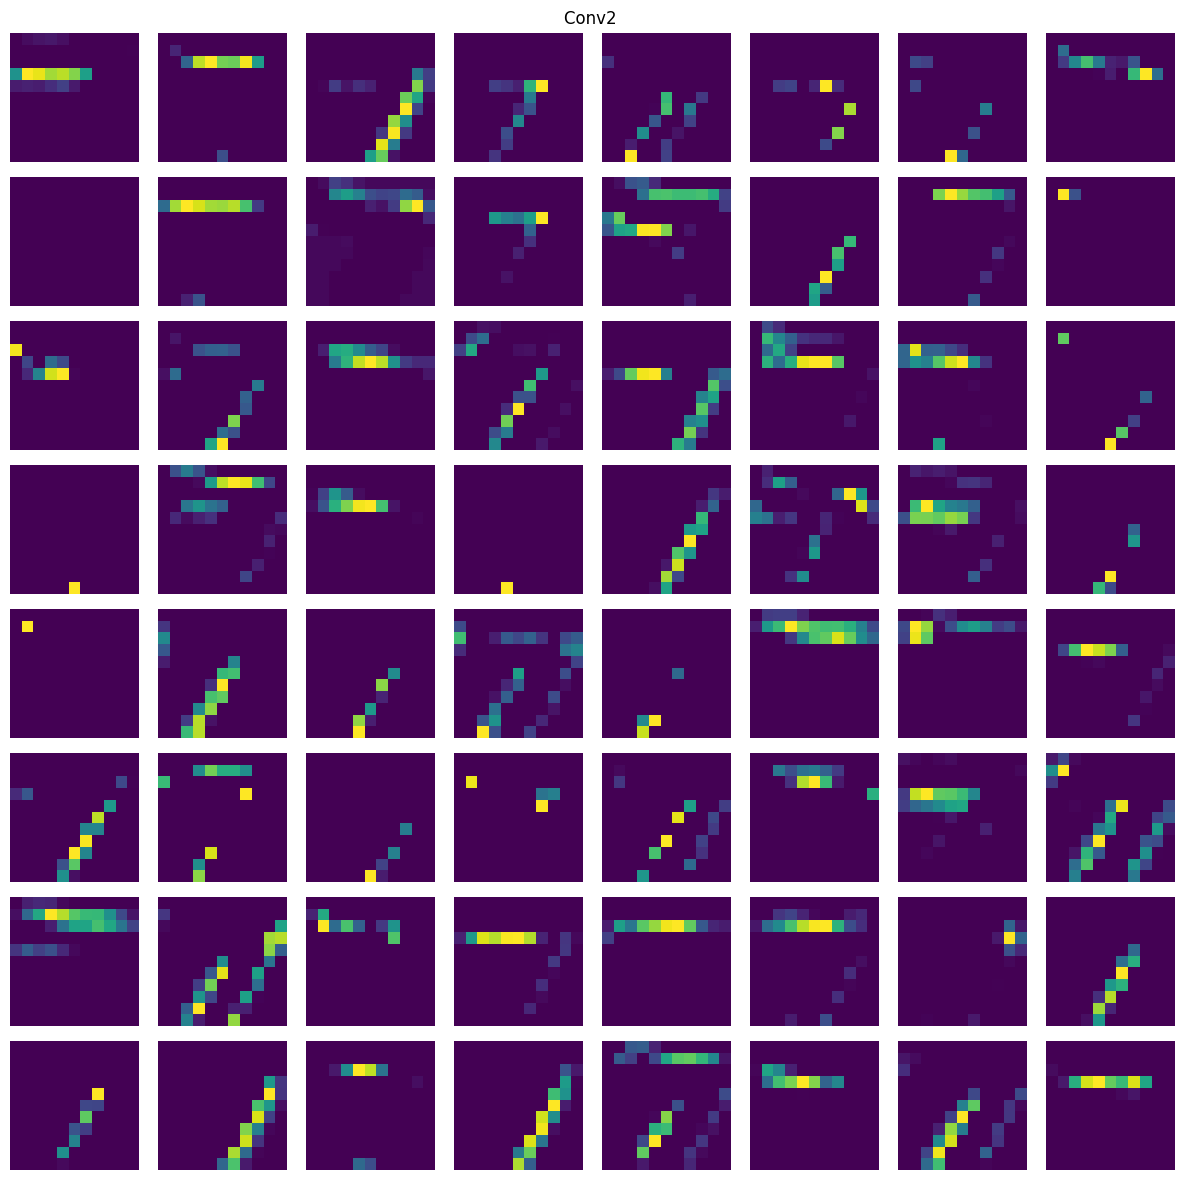

In [17]:
from matplotlib import pyplot as plt

input_tensor = keras.Input(shape=(28, 28, 1))
x = cnn_model.layers[0](input_tensor)
act1 = x
x = cnn_model.layers[1](x)
x = cnn_model.layers[2](x)
act2 = x

activation_model = keras.Model(inputs=input_tensor, outputs=[act1, act2])

activations = activation_model.predict(x_test[0:1], verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(activations[0][0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('Conv1')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(activations[1][0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('Conv2 ')
plt.tight_layout()
plt.show()

Первый свёрточный слой обнаруживает простые локальные паттерны: вертикальные, горизонтальные и диагональные границы, изгибы и углы.
Второй свёрточный слой комбинирует эти простые признаки в более сложные структуры: несколько расположенных относительно друг друга прямых, дуги и тд.